# Prediction

In [69]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import yaml
import torch
from PIL import Image
from tqdm import tqdm

sys.path.append('..')

# Chargement de la configuration M2UNet
config_path = '../configs/config_m2unet.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Configuration M2UNet chargée")
print(f"| Device: {device}")
print(f"| Modèle: {config['model']['name']}")
print(f"| Taille image: {config['data']['image_size']}")

Configuration M2UNet chargée
| Device: cuda
| Modèle: M2Unet
| Taille image: 256


## Données

In [70]:
# Chargement des chemins depuis la config
test_img_path = config['data']['test_img_path']
test_label_path = config['data']['test_label_path']

test_img_files = os.listdir(test_img_path)
test_label_files = os.listdir(test_label_path)

test_img = [os.path.join(test_img_path, file) for file in test_img_files]
test_label = [os.path.join(test_label_path, file) for file in test_label_files]

print(f'Number of testing images: {len(test_img)}')
print(f'Number of testing labels: {len(test_label)}')

Number of testing images: 200
Number of testing labels: 200


In [71]:
def load_img(file_path):
    return Image.open(file_path)

def load_label(file_path):
    # In grayscale (1 canal)
    return Image.open(file_path).convert('L')

## Chargement du modèle M2UNet

In [72]:
from src.utils.resume_training import load_pretrained_m2unet

# Charger le modèle M2UNet adapté (fine-tuné)
adapted_model_path = config['prediction'].get('prediction_model_path')
model_basis_path = config['model'].get('model_basis')

# Priorité: modèle adapté > modèle pré-entraîné de base
if adapted_model_path and os.path.isfile(adapted_model_path):
    model = load_pretrained_m2unet(adapted_model_path, device)
    print(f"Modèle adapté chargé: {adapted_model_path}")
else:
    raise FileNotFoundError("Aucun modèle M2UNet trouvé.")

model.eval()
print(f"Modèle M2UNet prêt pour la prédiction")

Modèle M2UNet pré-entraîné chargé depuis: ../saved_models/m2unet/256_DICE_BCE/best_model.pth
Modèle adapté chargé: ../saved_models/m2unet/256_DICE_BCE/best_model.pth
Modèle M2UNet prêt pour la prédiction


In [73]:
import torchvision.transforms as transforms
from torchvision.transforms import InterpolationMode
from src.dataset.dataset import VesselDataset
from torch.utils.data import DataLoader

# Paramètres depuis la config
image_size = config['data']['image_size']

image_transform = transforms.Compose([
    transforms.Resize((image_size, image_size), interpolation=InterpolationMode.BILINEAR),
    transforms.ToTensor(),
])

label_transform = transforms.Compose([
    transforms.Resize((image_size, image_size), interpolation=InterpolationMode.NEAREST),
    transforms.ToTensor(),
])

test_dataset = VesselDataset(
    test_img, 
    test_label, 
    image_transform=image_transform,
    label_transform=label_transform,
    quality_file="../data/Quality_Assessment.xlsx"
)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(f"Test dataset: {len(test_dataset)} images")
print(f"Quality map chargé: {len(test_dataset.quality_map)} entrées")

Test dataset: 200 images
Quality map chargé: 750 entrées


## Prédictions

In [74]:
from src.models.predict import predict

preds, f1_scores, precisions, recalls = predict(model, test_loader, device, config['parameters']['verbose'])

quality_sums = []
for idx in range(len(test_dataset)):
    quality = test_dataset.find_quality_from_quality_assessment(test_dataset.image_paths[idx])
    if quality is not None and quality["IC"] != -1:
        quality_sums.append(quality["IC"] + quality["Blur"] + quality["LC"])
    else:
        quality_sums.append(None)

print(f"Prédictions générées: {len(preds)} images")

print(f"Performances globales ({len(preds)} images)")
print(f"| F1-score : {np.mean(f1_scores):.4f}")
print(f"| Precision : {np.mean(precisions):.4f}")
print(f"| Recall   : {np.mean(recalls):.4f}")

for q_val in [0, 1, 2, 3]:
    indices = [i for i, q in enumerate(quality_sums) if q == q_val]
    if indices:
        q_f1 = np.mean([f1_scores[i] for i in indices])
        q_acc = np.mean([precisions[i] for i in indices])
        q_rec = np.mean([recalls[i] for i in indices])
        
        print(f"Qualité = {q_val} (IC+Blur+LC)  —  {len(indices)} images")
        print(f"| F1-score : {q_f1:.4f}")
        print(f"| Precision : {q_acc:.4f}")
        print(f"| Recall   : {q_rec:.4f}")
    else:
        print(f"Qualité = {q_val} : aucune image")

100%|██████████| 200/200 [00:29<00:00,  6.70it/s]

Prédictions générées: 200 images
Performances globales (200 images)
| F1-score : 0.7809
| Precision : 0.8456
| Recall   : 0.7374
Qualité = 0 (IC+Blur+LC)  —  15 images
| F1-score : 0.5195
| Precision : 0.7686
| Recall   : 0.4193
Qualité = 1 (IC+Blur+LC)  —  11 images
| F1-score : 0.6947
| Precision : 0.8317
| Recall   : 0.6030
Qualité = 2 (IC+Blur+LC)  —  41 images
| F1-score : 0.7798
| Precision : 0.8432
| Recall   : 0.7312
Qualité = 3 (IC+Blur+LC)  —  133 images
| F1-score : 0.8178
| Precision : 0.8562
| Recall   : 0.7863


## Visualisation

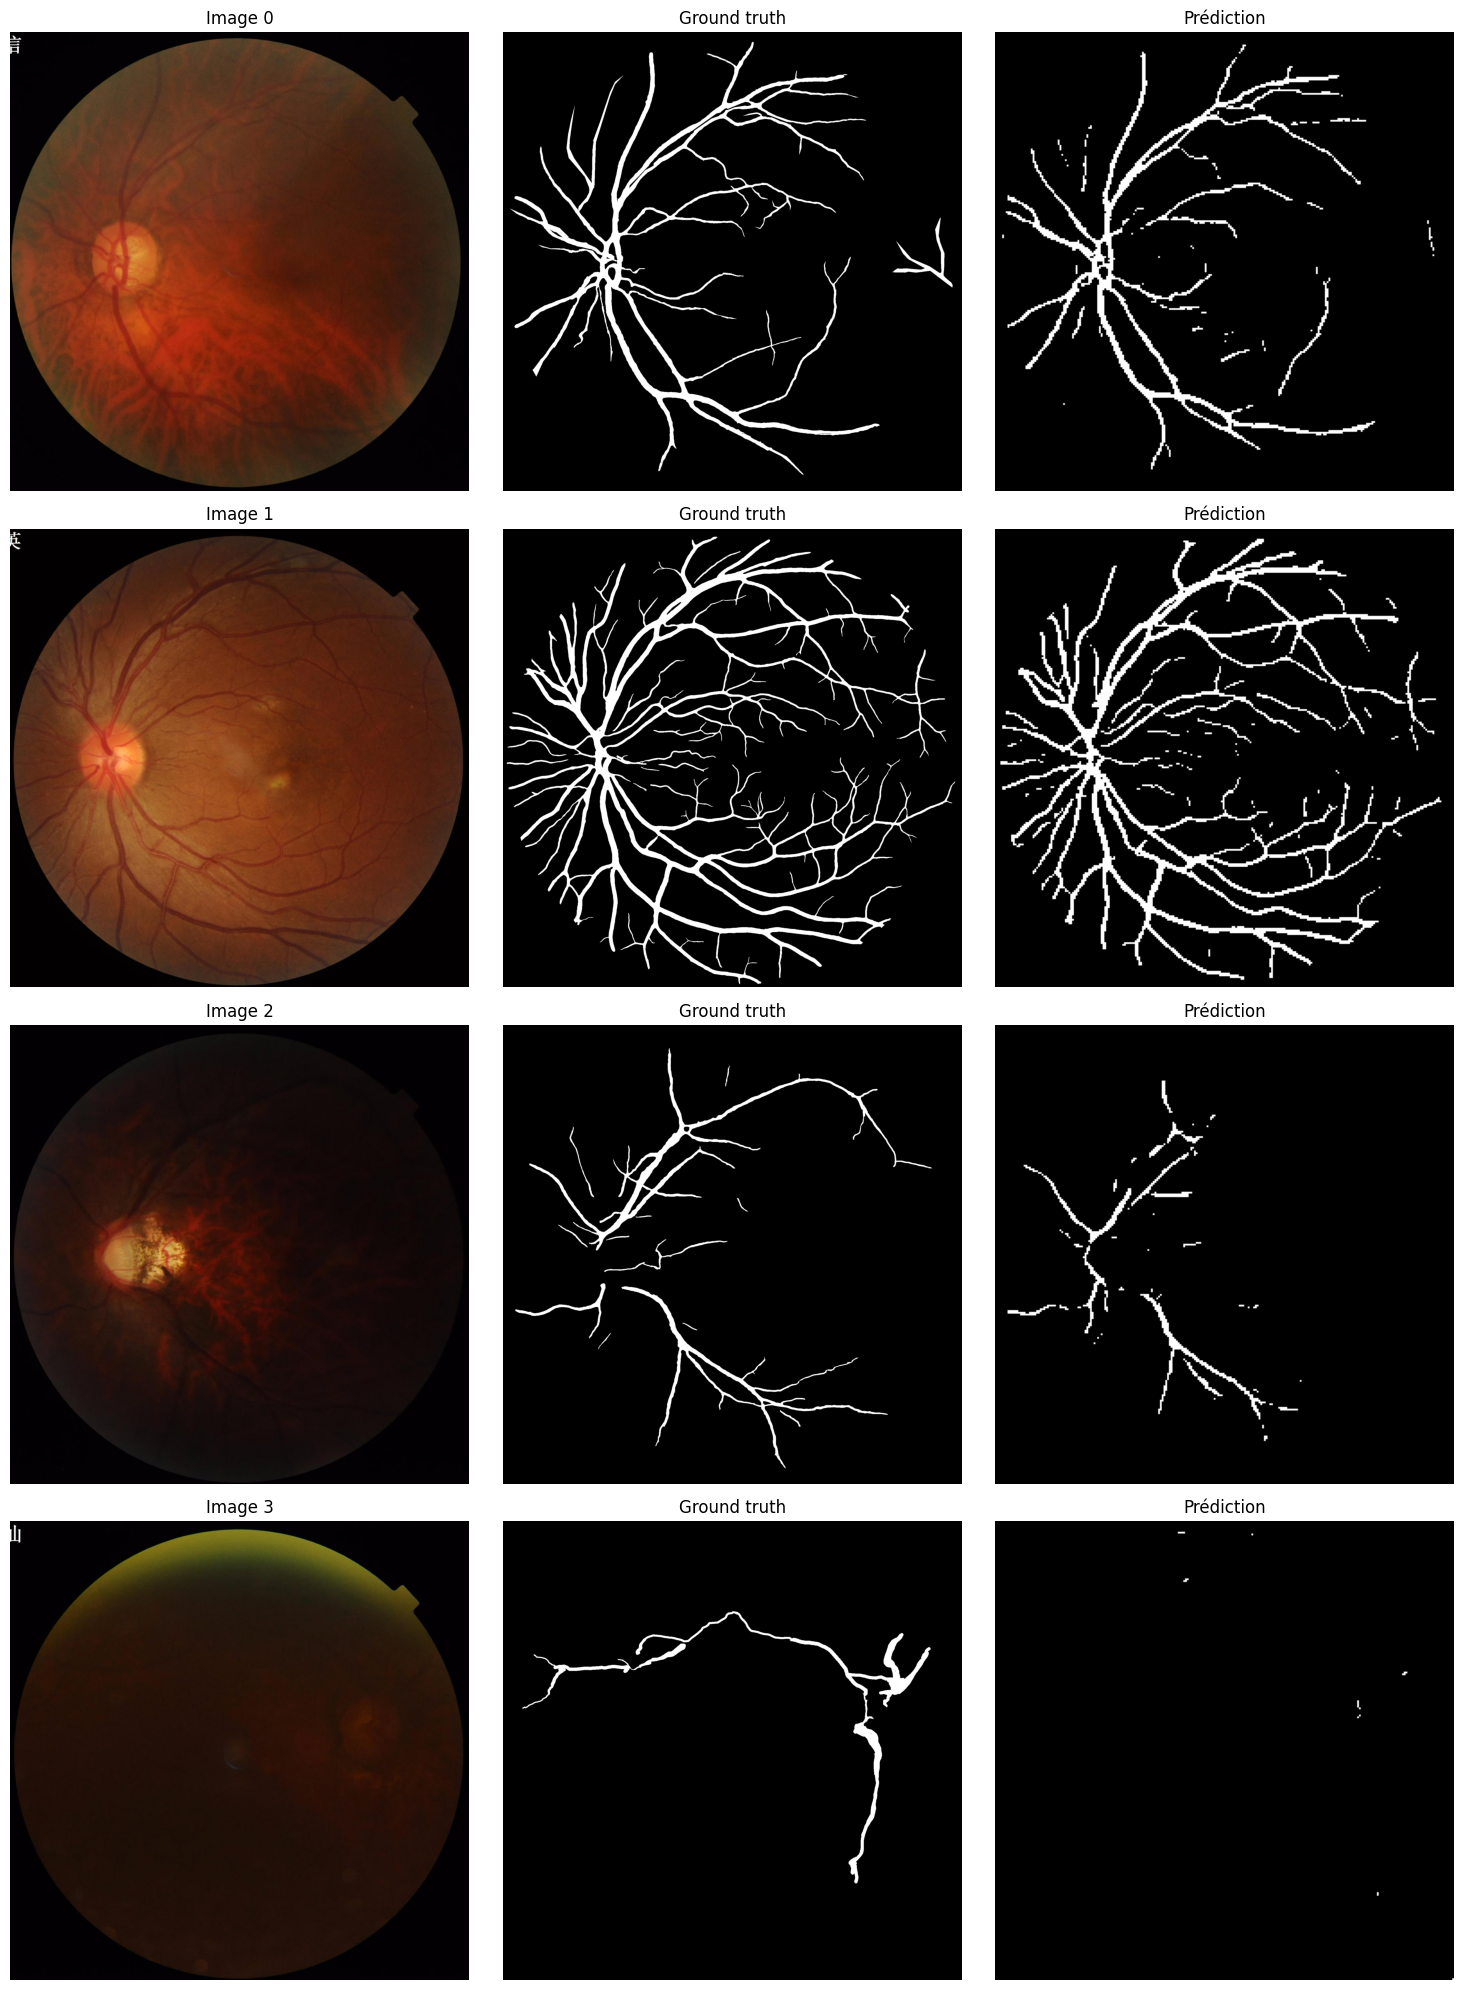

In [75]:
# Affichage de plusieurs prédictions
def visualize_predictions(test_imgs, test_labels, predictions, indices=[0, 1, 2, 3]):
    n = len(indices)
    fig, axes = plt.subplots(n, 3, figsize=(15, 5 * n))
    
    for i, idx in enumerate(indices):
        if idx >= len(predictions):
            continue
            
        # Image originale
        axes[i, 0].imshow(load_img(test_imgs[idx]))
        axes[i, 0].set_title(f'Image {idx}')
        axes[i, 0].axis('off')

        # Ground truth
        axes[i, 1].imshow(load_label(test_labels[idx]), cmap='gray')
        axes[i, 1].set_title('Ground truth')
        axes[i, 1].axis('off')

        # Prédiction
        pred = predictions[idx].to('cpu').squeeze().detach().numpy()
        axes[i, 2].imshow(pred, cmap='gray')
        axes[i, 2].set_title('Prédiction')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

# 4 premières
visualize_predictions(test_img, test_label, preds, indices=[0, 1, 2, 3])